# BK Sentinel — Notebook 03: Layer 2 Markov Chain Transition Matrix

**Project:** BK Sentinel — Three-Layer Dynamic Credit Risk Transition System  
**Author:** Denyse Mutoni Uwingeneye  
**Institution:** African Leadership University  

---

This notebook covers Layer 2 of BK Sentinel:
1. Load the empirical transition matrix computed in Notebook 01
2. Verify the matrix is valid (row sums, absorbing state)
3. Compute multi-step forecasts — 3, 6 months ahead
4. Visualise how the portfolio distribution evolves over time
5. Segment-level analysis — do Retail and SME customers transition differently?
6. Save all forecasts for the dashboard

**Key idea:** If we know the probability of moving from one risk state to another in one month (the transition matrix P), we can forecast any number of months ahead by raising P to the power of n. P² gives 2-month forecasts, P³ gives 3-month forecasts, and so on.

## 0. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from numpy.linalg import matrix_power

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

STATES = ['Low', 'Medium', 'High', 'Default']
COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c', 'Default': '#8e44ad'}

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load the empirical transition matrix

This matrix was computed in Notebook 01 from 15 consecutive monthly transition pairs across the 16-month panel. Each cell P[i][j] represents the probability that a loan account in state i this month will be in state j next month.

In [2]:
# Load the transition matrix
P_df = pd.read_csv('bk_transition_matrix.csv', index_col=0)
P_df = P_df.reindex(index=STATES, columns=STATES)
P = P_df.values  # convert to numpy array for matrix operations

print('Empirical Monthly Transition Matrix P:')
print(P_df.round(4))
print()
print('Row sums (must all equal 1.000):')
print(P_df.sum(axis=1).round(4))

Empirical Monthly Transition Matrix P:
              Low  Medium   High  Default
risk_state                               
Low        0.9303  0.0676 0.0021   0.0000
Medium     0.1778  0.7174 0.1047   0.0000
High       0.0000  0.0559 0.7002   0.2439
Default    0.0000  0.0000 0.0216   0.9784

Row sums (must all equal 1.000):
risk_state
Low       1.0000
Medium    0.9999
High      1.0000
Default   1.0000
dtype: float64


In [3]:
import pandas as pd
import numpy as np

df_comp = pd.read_csv('bk_sentinel_model_comparison.csv', low_memory=False)
STATES  = ['Low', 'Medium', 'High', 'Default']
model_names = ['logistic_regression', 'random_forest', 'xgboost']
matrices = {}

print('Transition matrix comparison — key rates')
print('=' * 60)
print(f'{"Model":<25} {"High→Default":>14} {"Med→High":>10} {"Default persist":>16}')
print('-' * 60)

for mn in model_names:
    pred_col = f'pred_{mn}'
    df_t = df_comp.copy()
    df_t['next_pred'] = df_t.groupby('loan_id')[pred_col].shift(-1)
    df_t = df_t.dropna(subset=['next_pred'])
    counts = pd.crosstab(df_t[pred_col], df_t['next_pred'])
    counts = counts.reindex(index=STATES, columns=STATES, fill_value=0)
    matrix = counts.div(counts.sum(axis=1).replace(0,1), axis=0)
    matrices[mn] = matrix
    h2d = matrix.loc['High','Default']
    m2h = matrix.loc['Medium','High']
    dp  = matrix.loc['Default','Default']
    print(f'{mn.replace("_"," ").title():<25} {h2d*100:>13.1f}% {m2h*100:>9.1f}% {dp*100:>15.1f}%')

P_emp = pd.read_csv('bk_transition_matrix.csv', index_col=0)
P_emp = P_emp.reindex(index=STATES, columns=STATES)
print('-' * 60)
print(f'{"Empirical (ground truth)":<25} {P_emp.loc["High","Default"]*100:>13.1f}% {P_emp.loc["Medium","High"]*100:>9.1f}% {P_emp.loc["Default","Default"]*100:>15.1f}%')

print('\nMAE vs empirical matrix (lower = better):')
for mn in model_names:
    mae = abs(matrices[mn].values - P_emp.values).mean()
    print(f'  {mn.replace("_"," ").title():<25}: {mae:.4f}')

Transition matrix comparison — key rates
Model                       High→Default   Med→High  Default persist
------------------------------------------------------------
Logistic Regression                24.4%       2.6%            97.8%
Random Forest                      21.8%       8.4%            98.0%
Xgboost                            21.9%       9.5%            97.8%
------------------------------------------------------------
Empirical (ground truth)           24.4%      10.5%            97.8%

MAE vs empirical matrix (lower = better):
  Logistic Regression      : 0.0402
  Random Forest            : 0.0116
  Xgboost                  : 0.0052


## 2. Verify the matrix — Level 3 check

Before using the matrix for forecasting we run three checks:
- All row sums equal 1.0 (probabilities are valid)
- Default has the highest self-transition probability (near-absorbing)
- No negative values

In [4]:
print('=' * 55)
print('LAYER 2 VERIFICATION CHECKS')
print('=' * 55)

# Check 1: row sums
row_sums = P.sum(axis=1)
row_sum_ok = all(abs(row_sums - 1.0) < 0.001)
print(f'\nCheck 1 — Row sums equal 1.000: {"PASS" if row_sum_ok else "FAIL"}')
for state, s in zip(STATES, row_sums):
    print(f'  {state:<10} {s:.4f}')

# Check 2: Default is near-absorbing (>= 0.95)
default_self = P[STATES.index('Default'), STATES.index('Default')]
absorbing_ok = default_self >= 0.95
print(f'\nCheck 2 — Default self-transition >= 0.95: {"PASS" if absorbing_ok else "FAIL"}')
print(f'  Default self-transition probability: {default_self:.4f}')
print(f'  Absorbing state criterion: {"SATISFIED" if absorbing_ok else "NOT SATISFIED"}')

# Check 3: no negative values
no_negatives = (P >= 0).all()
print(f'\nCheck 3 — No negative probabilities: {"PASS" if no_negatives else "FAIL"}')

print()
if row_sum_ok and absorbing_ok and no_negatives:
    print('All checks PASSED. Matrix is valid for forecasting.')
else:
    print('Some checks FAILED. Review before proceeding.')

LAYER 2 VERIFICATION CHECKS

Check 1 — Row sums equal 1.000: PASS
  Low        1.0000
  Medium     0.9999
  High       1.0000
  Default    1.0000

Check 2 — Default self-transition >= 0.95: PASS
  Default self-transition probability: 0.9784
  Absorbing state criterion: SATISFIED

Check 3 — No negative probabilities: PASS

All checks PASSED. Matrix is valid for forecasting.


## 3. Visualise the 1-month transition matrix as a heatmap

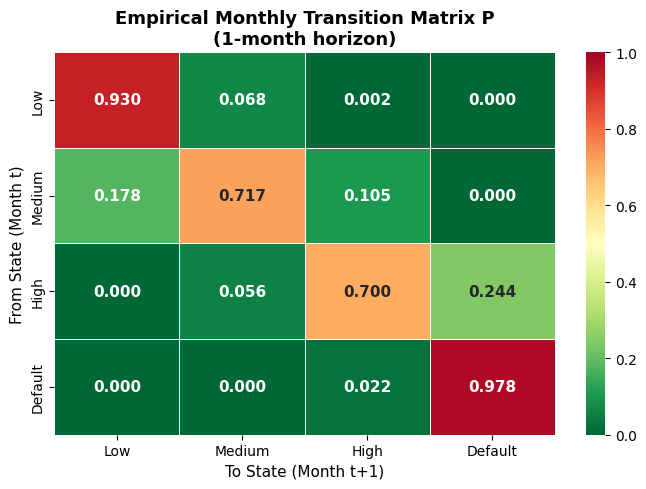

Chart saved.


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    P_df, annot=True, fmt='.3f',
    cmap='RdYlGn_r', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 11, 'weight': 'bold'}
)
ax.set_title('Empirical Monthly Transition Matrix P\n(1-month horizon)', fontsize=13, fontweight='bold')
ax.set_xlabel('To State (Month t+1)', fontsize=11)
ax.set_ylabel('From State (Month t)', fontsize=11)
plt.tight_layout()
plt.savefig('03_transition_matrix_1month.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## 4. Multi-step forecasting — raising P to successive powers

The core insight of Markov chain forecasting is simple:

- **1 month ahead**: P¹ = P (the matrix itself)
- **3 months ahead**: P³ = P × P × P
- **6 months ahead**: P⁶ = P × P × P × P × P × P

Each entry in Pⁿ gives the probability of moving from state i to state j over exactly n months, accounting for all possible paths in between.

In [6]:
# Compute matrix powers
horizons = [1, 3, 6]
forecasts = {}

for n in horizons:
    Pn = matrix_power(P, n)
    forecasts[n] = pd.DataFrame(Pn, index=STATES, columns=STATES)
    print(f'P^{n} — {n}-month forecast:')
    print(forecasts[n].round(4))
    print(f'Row sums: {Pn.sum(axis=1).round(4).tolist()}')
    print()

P^1 — 1-month forecast:
           Low  Medium   High  Default
Low     0.9303  0.0676 0.0021   0.0000
Medium  0.1778  0.7174 0.1047   0.0000
High    0.0000  0.0559 0.7002   0.2439
Default 0.0000  0.0000 0.0216   0.9784
Row sums: [1.0, 0.9999, 1.0, 1.0]

P^3 — 3-month forecast:
           Low  Medium   High  Default
Low     0.8361  0.1399 0.0209   0.0031
Medium  0.3672  0.4102 0.1611   0.0613
High    0.0233  0.0855 0.3682   0.5229
Default 0.0002  0.0029 0.0463   0.9506
Row sums: [1.0, 0.9998, 1.0, 1.0]

P^6 — 6-month forecast:
           Low  Medium   High  Default
Low     0.7510  0.1761 0.0478   0.0250
Medium  0.4614  0.2336 0.1359   0.1687
High    0.0596  0.0714 0.1741   0.6949
Default 0.0025  0.0079 0.0615   0.9280
Row sums: [0.9999, 0.9997, 1.0, 1.0]



## 5. Visualise all four horizons as heatmaps

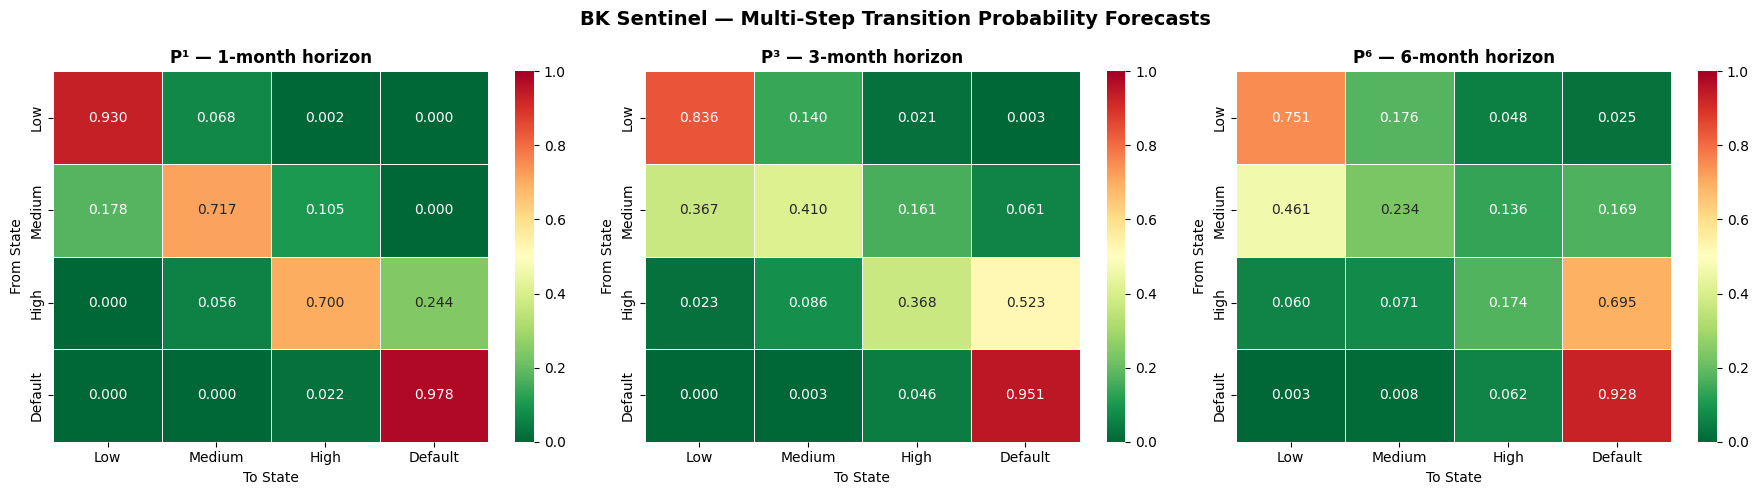

Multi-step forecast heatmaps saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = {
    1: 'P¹ — 1-month horizon',
    3: 'P³ — 3-month horizon',
    6: 'P⁶ — 6-month horizon',
}

for ax, n in zip(axes, horizons):
    sns.heatmap(
        forecasts[n], annot=True, fmt='.3f',
        cmap='RdYlGn_r', vmin=0, vmax=1,
        linewidths=0.5, ax=ax,
        annot_kws={'size': 10}
    )
    ax.set_title(titles[n], fontsize=12, fontweight='bold')
    ax.set_xlabel('To State', fontsize=10)
    ax.set_ylabel('From State', fontsize=10)

plt.suptitle('BK Sentinel — Multi-Step Transition Probability Forecasts',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_multistep_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Multi-step forecast heatmaps saved.')

## 6. Portfolio distribution forecast

Given the current portfolio distribution (how many accounts are in each state right now), we can forecast how that distribution will shift over time.

If we have a row vector π₀ representing the current portfolio distribution, then:
- Portfolio in n months = π₀ × Pⁿ

This tells us: given where the portfolio is today, what will it look like in 3, 6 months if current transition patterns continue?

In [8]:
# Load the verified dataset to get current portfolio distribution
df = pd.read_csv('bk_sentinel_verified.csv', low_memory=False)

# Use the most recent month as the current state
latest_month = df['observation_month'].max()
df_current = df[df['observation_month'] == latest_month]

# Compute current distribution as a probability vector
current_counts = df_current['risk_state'].value_counts()
total = current_counts.sum()
pi_0 = np.array([current_counts.get(s, 0) / total for s in STATES])

print(f'Current portfolio snapshot: {latest_month}')
print(f'Total accounts: {total:,}')
print()
print('Current distribution (π₀):')
for state, prob, count in zip(STATES, pi_0, [current_counts.get(s, 0) for s in STATES]):
    print(f'  {state:<10} {count:>6,} accounts  ({prob*100:.1f}%)')

Current portfolio snapshot: 2026-01
Total accounts: 4,244

Current distribution (π₀):
  Low         2,058 accounts  (48.5%)
  Medium        593 accounts  (14.0%)
  High          335 accounts  (7.9%)
  Default     1,258 accounts  (29.6%)


In [9]:
# Forecast portfolio distribution at each horizon
print('Portfolio distribution forecasts:')
print(f'{"Horizon":<15} {"Low":>8} {"Medium":>8} {"High":>8} {"Default":>8}')
print('-' * 50)

distribution_forecasts = {}
all_horizons = [0, 1, 3, 6]

for n in all_horizons:
    if n == 0:
        pi_n = pi_0
        label = 'Now'
    else:
        Pn = matrix_power(P, n)
        pi_n = pi_0 @ Pn
        label = f'{n} month{"s" if n > 1 else ""}'
    distribution_forecasts[n] = pi_n
    print(f'{label:<15} {pi_n[0]*100:>7.1f}% {pi_n[1]*100:>7.1f}% {pi_n[2]*100:>7.1f}% {pi_n[3]*100:>7.1f}%')

Portfolio distribution forecasts:
Horizon              Low   Medium     High  Default
--------------------------------------------------
Now                48.5%    14.0%     7.9%    29.6%
1 month            47.6%    13.7%     7.7%    30.9%
3 months           45.9%    13.3%     7.5%    33.3%
6 months           43.4%    12.6%     7.4%    36.6%


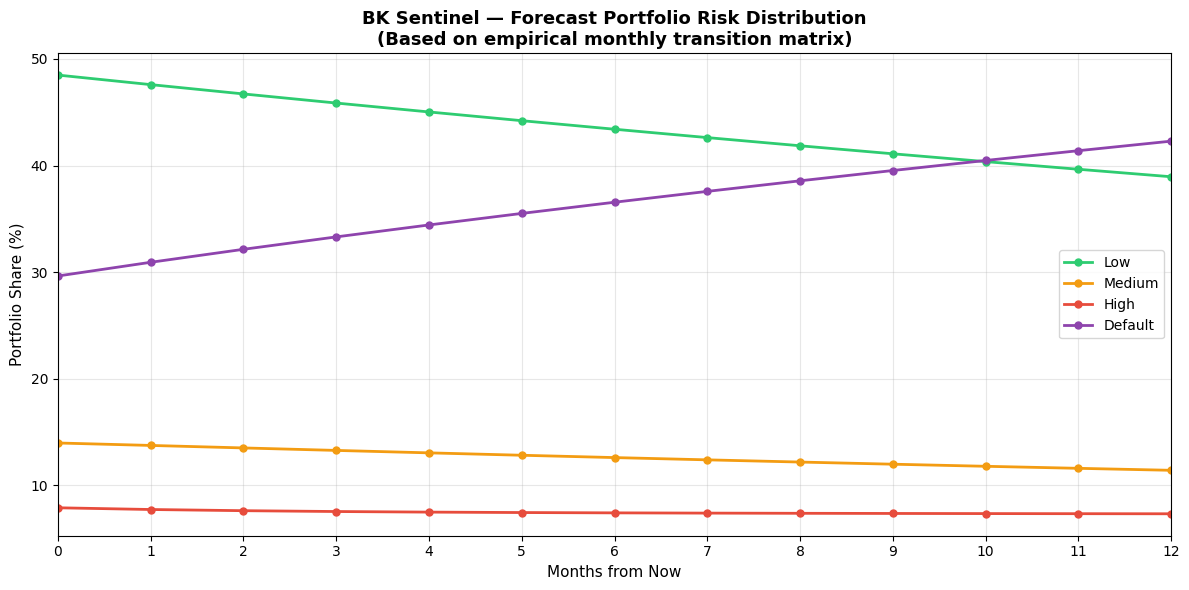

Portfolio evolution chart saved.


In [10]:
# Visualise portfolio evolution over time
fig, ax = plt.subplots(figsize=(12, 6))

# Compute at every month from 0 to 6
month_range = range(0, 13)
evolution = {state: [] for state in STATES}

for n in month_range:
    if n == 0:
        pi_n = pi_0
    else:
        pi_n = pi_0 @ matrix_power(P, n)
    for i, state in enumerate(STATES):
        evolution[state].append(pi_n[i] * 100)

for state in STATES:
    ax.plot(list(month_range), evolution[state],
            marker='o', markersize=5, linewidth=2,
            label=state, color=COLORS[state])

ax.set_xlabel('Months from Now', fontsize=11)
ax.set_ylabel('Portfolio Share (%)', fontsize=11)
ax.set_title('BK Sentinel — Forecast Portfolio Risk Distribution\n(Based on empirical monthly transition matrix)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.set_xlim(0, 12)

plt.tight_layout()
plt.savefig('03_portfolio_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Portfolio evolution chart saved.')

## 7. Segment-level transition analysis

Do Retail, SME, Agriculture, and Corporate customers transition between risk states at different rates? This section computes a separate transition matrix for each segment and compares them.

In [11]:
# Load transitions dataset
df_trans = pd.read_csv('bk_sentinel_transitions.csv', low_memory=False)

# Get unique segments
segments = [s for s in df_trans['segment'].unique() if s != 'UNKNOWN']
print(f'Segments found: {segments}')
print()

segment_matrices = {}

for seg in segments:
    df_seg = df_trans[df_trans['segment'] == seg]
    counts = pd.crosstab(df_seg['risk_state'], df_seg['next_risk_state'])
    counts = counts.reindex(index=STATES, columns=STATES, fill_value=0)
    # Only compute matrix if we have enough data
    if len(df_seg) > 50:
        matrix = counts.div(counts.sum(axis=1).replace(0, 1), axis=0)
        segment_matrices[seg] = matrix
        print(f'Segment: {seg} ({len(df_seg):,} transition pairs)')
        print(f'  Default self-transition: {matrix.loc["Default", "Default"]:.4f}')
        print(f'  High -> Default:         {matrix.loc["High", "Default"]:.4f}')
        print(f'  Medium -> Low recovery:  {matrix.loc["Medium", "Low"]:.4f}')
        print()

Segments found: ['RETAIL', 'AGRICULTURE', 'SME', 'CORPORATE']

Segment: RETAIL (56,160 transition pairs)
  Default self-transition: 0.9784
  High -> Default:         0.2443
  Medium -> Low recovery:  0.1777

Segment: AGRICULTURE (1,230 transition pairs)
  Default self-transition: 0.9706
  High -> Default:         0.4706
  Medium -> Low recovery:  0.1862

Segment: SME (3,000 transition pairs)
  Default self-transition: 0.9834
  High -> Default:         0.1955
  Medium -> Low recovery:  0.1887

Segment: CORPORATE (510 transition pairs)
  Default self-transition: 0.9595
  High -> Default:         0.3226
  Medium -> Low recovery:  0.2321



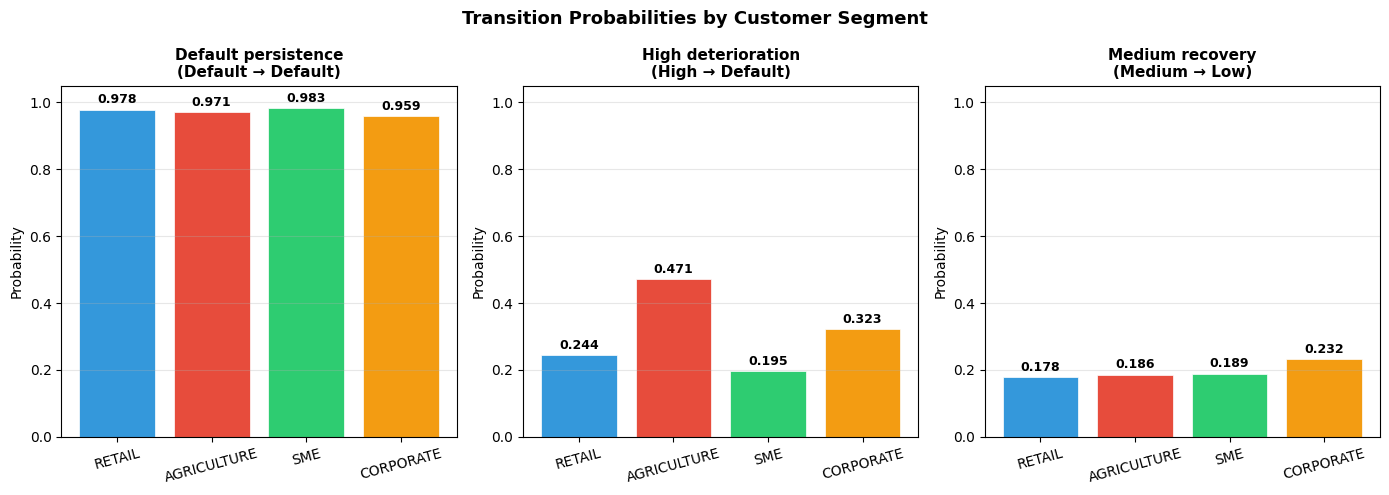

Segment comparison chart saved.


In [12]:
# Plot segment comparison — focus on three key transitions
if len(segment_matrices) >= 2:
    segs = list(segment_matrices.keys())

    metrics = {
        'Default persistence\n(Default → Default)': [segment_matrices[s].loc['Default', 'Default'] for s in segs],
        'High deterioration\n(High → Default)': [segment_matrices[s].loc['High', 'Default'] for s in segs],
        'Medium recovery\n(Medium → Low)': [segment_matrices[s].loc['Medium', 'Low'] for s in segs],
    }

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for ax, (metric_name, values) in zip(axes, metrics.items()):
        bars = ax.bar(segs, values,
                      color=bar_colors[:len(segs)],
                      edgecolor='white', linewidth=0.5)
        ax.set_title(metric_name, fontsize=11, fontweight='bold')
        ax.set_ylabel('Probability', fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', rotation=15)

    plt.suptitle('Transition Probabilities by Customer Segment', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('03_segment_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Segment comparison chart saved.')
else:
    print('Not enough segments with sufficient data for comparison.')

## 8. Key findings summary

In [13]:
print('=' * 60)
print('LAYER 2 KEY FINDINGS')
print('=' * 60)

print('\n1-month transition probabilities:')
print(f'  Low self-retention:       {P[0,0]:.4f} ({P[0,0]*100:.1f}% stay Low)')
print(f'  Medium -> Low recovery:   {P[1,0]:.4f} ({P[1,0]*100:.1f}% recover per month)')
print(f'  High -> Default:          {P[2,3]:.4f} ({P[2,3]*100:.1f}% deteriorate per month)')
print(f'  Default persistence:      {P[3,3]:.4f} ({P[3,3]*100:.1f}% remain in Default)')

print('\nMulti-step Default absorption (starting from High risk):')
for n in [1, 3, 6]:
    prob = forecasts[n].loc['High', 'Default']
    print(f'  {n:>2} month(s): {prob:.4f} ({prob*100:.1f}% probability of reaching Default)')

print('\nPortfolio Default share forecast:')
for n in [0, 3, 6]:
    pct = distribution_forecasts[n][STATES.index('Default')] * 100
    label = 'Now' if n == 0 else f'In {n} months'
    print(f'  {label:<12}: {pct:.1f}% of portfolio in Default')

print()
print('Next: Run Notebook 04 — Layer 3 Absorption State Analysis')

LAYER 2 KEY FINDINGS

1-month transition probabilities:
  Low self-retention:       0.9303 (93.0% stay Low)
  Medium -> Low recovery:   0.1778 (17.8% recover per month)
  High -> Default:          0.2439 (24.4% deteriorate per month)
  Default persistence:      0.9784 (97.8% remain in Default)

Multi-step Default absorption (starting from High risk):
   1 month(s): 0.2439 (24.4% probability of reaching Default)
   3 month(s): 0.5229 (52.3% probability of reaching Default)
   6 month(s): 0.6949 (69.5% probability of reaching Default)

Portfolio Default share forecast:
  Now         : 29.6% of portfolio in Default
  In 3 months : 33.3% of portfolio in Default
  In 6 months : 36.6% of portfolio in Default

Next: Run Notebook 04 — Layer 3 Absorption State Analysis


## 9. Save outputs for dashboard

In [15]:
import json

# Save all forecast matrices
for n in horizons:
    forecasts[n].to_csv(f'bk_forecast_{n}month.csv')

# Save portfolio distribution forecasts
dist_records = []
for n in all_horizons:
    row = {'horizon_months': n}
    for state, prob in zip(STATES, distribution_forecasts[n]):
        row[state] = round(prob, 6)
    dist_records.append(row)
pd.DataFrame(dist_records).to_csv('bk_portfolio_forecasts.csv', index=False)

# Save segment matrices
for seg, matrix in segment_matrices.items():
    safe_name = seg.replace(' ', '_').upper()
    matrix.to_csv(f'bk_transition_{safe_name}.csv')

print('Files saved:')
print('  bk_forecast_1month.csv    — 1-month transition forecast')
print('  bk_forecast_3month.csv    — 3-month transition forecast')
print('  bk_forecast_6month.csv    — 6-month transition forecast')
print('  bk_portfolio_forecasts.csv — portfolio distribution at each horizon')
for seg in segment_matrices:
    safe = seg.replace(' ', '_').upper()
    print(f'  bk_transition_{safe}.csv')

Files saved:
  bk_forecast_1month.csv    — 1-month transition forecast
  bk_forecast_3month.csv    — 3-month transition forecast
  bk_forecast_6month.csv    — 6-month transition forecast
  bk_portfolio_forecasts.csv — portfolio distribution at each horizon
  bk_transition_RETAIL.csv
  bk_transition_AGRICULTURE.csv
  bk_transition_SME.csv
  bk_transition_CORPORATE.csv
